In [2]:
import numpy as np

# Spettri
s = np.load('../data/10k/X_spectra_10k.npy')#, mmap_mode='r')
# Corrispondenti campi magnetici
B = np.load('../data/10k/Y_B_field_10k.npy')
# Asse x (frequenze)
f = np.arange(2500, 3250) 
x_axis = range(2500, 3250)
# Labels
posizioni_fit_tot = np.loadtxt('../data/10k/posizioni_fit_otto_pseudo_voigt.txt', delimiter=',')

N_spettri, N_punti = s.shape[0], s.shape[1]

Provo ad addestrare un LSTM a prevedere le posizioni dei picchi a partire dagli spettri


In [3]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# ==========================================
# 1. CARICAMENTO E PREPARAZIONE DEI DATI
# ==========================================

# Supponiamo che 's' sia il tuo array di 10k spettri (es. shape: (10000, N_punti))
# e 'posizioni_fit_tot' sia il tuo array di labels (shape: (10000, 8))
# Sostituisci queste due righe con il caricamento effettivo dei tuoi dati se sono su file
# X_raw = np.load('spettri.npy') 
# y_raw = np.loadtxt('../data/10k/posizioni_fit_otto_pseudo_voigt.txt', delimiter=',')

X_raw = s  # Shape attesa: (10000, N_punti)
y_raw = posizioni_fit_tot  # Shape attesa: (10000, 8)

# Normalizzazione degli input (Spettri) e degli output (Posizioni)
# Usiamo MinMaxScaler per portare tutto nel range [0, 1], ideale per le reti neurali
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# Per scalare X, dobbiamo prima "appiattirlo", scalarlo e poi rimetterlo a posto
X_scaled = scaler_X.fit_transform(X_raw.T).T 
y_scaled = scaler_y.fit_transform(y_raw)

# Reshape di X per la LSTM: (campioni, timestep, features)
# features = 1 perché ad ogni "passo" (frequenza) hai un solo valore (l'intensità)
N_campioni, N_punti = X_scaled.shape
X_lstm = X_scaled.reshape((N_campioni, N_punti, 1))

# Divisione Train/Test (80% addestramento, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_lstm, y_scaled, test_size=0.20, random_state=42)

print(f"Shape X_train: {X_train.shape}")
print(f"Shape y_train: {y_train.shape}")
print(f"Shape X_test: {X_test.shape}")

# ==========================================
# 2. COSTRUZIONE DELL'ARCHITETTURA LSTM
# ==========================================

modello = Sequential()

# Input layer per esplicitare la shape iniziale
modello.add(Input(shape=(N_punti, 1)))

# Primo layer LSTM
# return_sequences=False perché vogliamo un solo output (le 8 posizioni) alla fine di tutta la sequenza
modello.add(LSTM(64, activation='tanh', return_sequences=False))

# Layer di Output
# 8 neuroni con attivazione lineare (di default) perché stiamo facendo un'operazione di regressione
modello.add(Dense(8))

# Compilazione del modello
# Usiamo Mean Squared Error (MSE) come funzione di perdita e Adam come ottimizzatore
modello.compile(optimizer='adam', loss='mse', metrics=['mae'])

modello.summary()

# ==========================================
# 3. ADDESTRAMENTO
# ==========================================

# EarlyStopping ferma l'addestramento se il modello smette di migliorare sul validation set,
# evitando l'overfitting e facendoti risparmiare tempo.
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Fit del modello
history = modello.fit(
    X_train, 
    y_train,
    epochs=100,             # Numero massimo di iterazioni (verrà fermato prima dall'EarlyStopping se converge)
    batch_size=64,          # Quanti spettri processare insieme (aumentalo a 128 o 256 per maggiore velocità)
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

# ==========================================
# 4. INFERENZA E RICONVERSIONE
# ==========================================

# Testiamo il modello facendo una predizione sul set di test
predizioni_scalatate = modello.predict(X_test)

# Le predizioni sono tra 0 e 1, dobbiamo riportarle alle frequenze reali (es. 2870)
predizioni_reali = scaler_y.inverse_transform(predizioni_scalatate)
y_test_reali = scaler_y.inverse_transform(y_test)

# Stampiamo il primo spettro di test per confronto
print("\nConfronto sul primo spettro di test (Valori reali vs Predetti):")
print(f"Reali:   {np.round(y_test_reali[0], 2)}")
print(f"Predetti:{np.round(predizioni_reali[0], 2)}")

Shape X_train: (8000, 750, 1)
Shape y_train: (8000, 8)
Shape X_test: (2000, 750, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,416 (68.03 KB)

 Trainable params: 17,416 (68.03 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 30s 232ms/step - loss: 0.1008 - mae: 0.2658 - val_loss: 0.0847 - val_mae: 0.2486
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 26s 207ms/step - loss: 0.0859 - mae: 0.2510 - val_loss: 0.0847 - val_mae: 0.2489
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 26s 205ms/step - loss: 0.0860 - mae: 0.2510 - val_loss: 0.0849 - val_mae: 0.2508
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 30s 239ms/step - loss: 0.0858 - mae: 0.2510 - val_loss: 0.0847 - val_mae: 0.2504
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 31s 248ms/step - loss: 0.0857 - mae: 0.2510 - val_loss: 0.0845 - val_mae: 0.2495
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 45s 361ms/step - loss: 0.0860 - mae: 0.2512 - val_loss: 0.0848 - val_mae: 0.2499
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 35s 278ms/step - loss: 0.0858 - mae: 0.2511 - val_loss: 0.0847 - val_mae: 0.2491
Epoch 8/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 33s 266ms/step - loss: 0.0859 - mae: 0.2511 - val_loss: 0.0847 - val_mae: 0.2501
Epoch 9/100
125/125 ━━━━

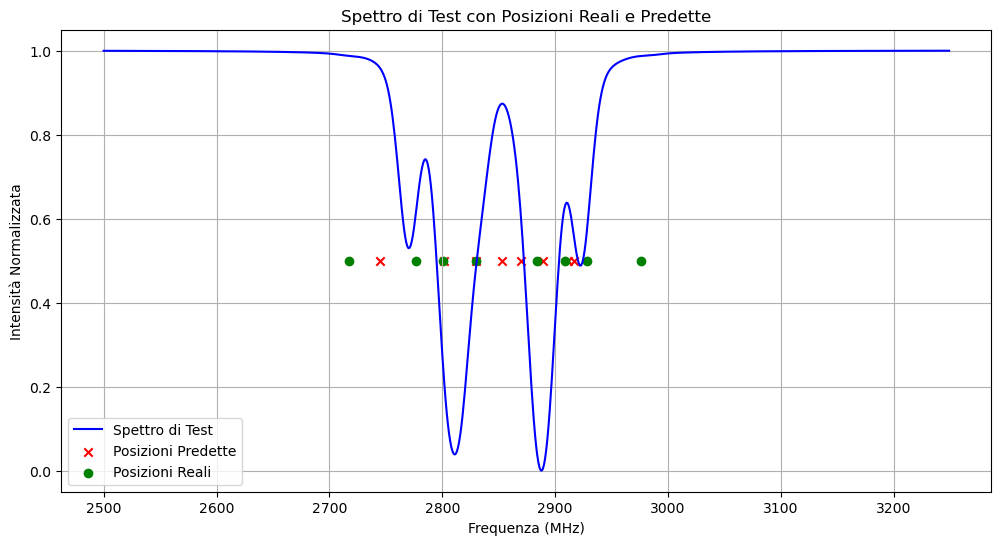

In [4]:
# plotto il primo spettro di test con le posizioni reali e predette
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(x_axis, X_test[0].reshape(-1), label='Spettro di Test', color='blue')
plt.scatter(predizioni_reali[0], [0.5]*8, label='Posizioni Predette', color='red', marker='x')
plt.scatter(y_test_reali[0], [0.5]*8, label='Posizioni Reali', color='green', marker='o')
plt.title('Spettro di Test con Posizioni Reali e Predette')
plt.xlabel('Frequenza (MHz)')
plt.ylabel('Intensità Normalizzata')
plt.legend()
plt.grid()
plt.show()